# Which alternative monotonicity metrics match which intuitions?

This notebook implements and stress-tests the twelve proposals in the prompt on
a transparent finite universe. Its conclusion is deliberately not "metric X
wins." The proposals encode at least four different intuitions:

1. **logical exactness:** one counterexample defeats monotonicity;
2. **repair distance:** few truth-value changes should mean nearly monotone;
3. **local regularity:** one-element changes should usually have the right sign;
4. **simple organization:** a small number of boundaries may be cognitively easy.

A metric can fit one intuition and fail another. To avoid letting a metric
define its own success, the notebook preregisters several qualitative tests
before examining the scores.

## Main findings

- Pairwise preservation and counterfactual robustness are the same estimand
  under uniform sampling of eligible comparable pairs.
- Edge preservation is the one-step version. It gives the clearest local
  interpretation and is a plausible **learnability hypothesis**, but this
  notebook does not establish a correlation with neural AUC.
- Nearest-monotone edit distance is the cleanest global "minimal repair"
  measure and performs well on the preregistered near-monotone ladder.
- Closure inflation is a transparent one-sided repair cost; closure precision
  can be misleading for highly prevalent truth sets.
- Switch count measures boundary simplicity, not directional monotonicity.
- Chain inversions generalize pairwise violations with a chain-sampling
  weighting; they are not independent of pairwise comparison.
- The derivative-sign score conditions only on edges where truth changes. It
  captures directional transition purity, not violation frequency.
- Context profiles and directional profiles are valuable **representations**,
  not competing scalar definitions.
- Threshold and LoT scores test restricted representational hypotheses. They
  should not be sold as general monotonicity measures.

## 1. What is actually distinct among the twelve proposals?

| Prompt proposal | Implementation here | Status |
|---|---|---|
| 1. Pairwise violation | conditional truth preservation over all comparable pairs | distinct weighting |
| 2. Hasse-edge violation | conditional truth preservation over cover edges | local version of 1 |
| 3. Nearest monotone | exact minimum Hamming edits via an s-t minimum cut | distinct repair metric |
| 4. Closure cost | normalized closure inflation and closure precision | one-sided repair metrics |
| 5. Switch count | excess switches averaged over maximal chains | nondirectional simplicity metric |
| 6. Chain score | inversions averaged over maximal chains | chain-weighted pair violations |
| 7. Robustness | survival by expansion distance `k`, then equal-`k` average | proposal 1 plus a sampling policy |
| 8. Derivative sign | favorable / all nonzero one-edge derivatives | local transition-sign metric |
| 9. Context sensitive | mean, SD, and coverage across fixed-argument contexts | profile, not one scalar |
| 10. Direction profile | four-vector plus max, mean, and purity | aggregation choice |
| 11. Threshold fit | best accuracy among simple cardinality thresholds | restricted model-family fit |
| 12. LoT fit | exception-code proxy based on minimum edits | **proxy only**, not a full LoT/MDL model |

The final row requires special caution. A real LoT score needs a specified
grammar, rule probabilities or code lengths, and inference over expressions.
Calling an exception count "LoT" would overstate what was measured, so the
notebook reports it as a transparent proxy.

## Data provenance: what generates what

All source and generated artifacts live in this repository:

1. `alternative_monotonicity_metrics.py` implements the metric formulas.
2. `scripts/alternative_monotonicity_metric_benchmark.py` constructs the
   exhaustive M4/X4 meaning suite, calls those formulas, and writes
   `analysis/alternative_monotonicity_metric_benchmark.csv`.
3. `scripts/build_alternative_monotonicity_metrics_notebook.py` generates this
   notebook.
4. This executed notebook reads the committed CSV for the M4/X4 comparison and
   directly calls `cardinality_lattice_scores` for the exact `n=2...100`
   parity-size sweep.

To rebuild the data and notebook from `src/examples/learn_quant/`:

```bash
python scripts/alternative_monotonicity_metric_benchmark.py
python scripts/build_alternative_monotonicity_metrics_notebook.py
jupyter nbconvert --to notebook --execute \
  notebooks/alternative_monotonicity_metrics_benchmark.ipynb \
  --output alternative_monotonicity_metrics_benchmark.ipynb
```

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "analysis").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import alternative_monotonicity_metrics as alt_metrics

CSV = ROOT / "analysis/alternative_monotonicity_metric_benchmark.csv"
df = pd.read_csv(CSV)

METRICS = {
    "majorant_entropy": "manuscript majorant entropy",
    "two_sided_min": "two-sided entropy minimum",
    "pairwise_preservation": "all-pair preservation",
    "edge_preservation": "edge preservation",
    "unconditional_pair": "unconditional pair score",
    "nearest_monotone_edit": "nearest-monotone edit",
    "closure_inflation": "closure inflation",
    "closure_precision": "closure precision",
    "chain_switch": "chain switch simplicity",
    "chain_inversion": "chain inversion",
    "equal_distance_robustness": "equal-distance robustness",
    "derivative_sign": "derivative sign",
    "context_mean": "mean context preservation",
    "best_simple_threshold": "best simple-threshold fit",
    "exception_code_proxy": "exception-code proxy",
}

print(
    f"{df.meaning.nunique()} meanings x {df.direction.nunique()} directions "
    f"= {len(df)} directional cases"
)

21 meanings x 4 directions = 84 directional cases


## 2. Benchmark universe and meanings

The universe is M4/X4: every ordered pair `(A,B)` of subsets of a four-element
domain, giving `16 x 16 = 256` situations. All displayed scores are exhaustive,
not Monte Carlo estimates.

The suite includes:

- textbook quantifiers (`all`, `some`, `no`, `not all`, `most`);
- monotone overlap and cardinality thresholds;
- organized nonmonotone bands (`exactly two`, `one through three`);
- alternating parity predicates;
- one deliberately near-monotone predicate with a single exceptional
  `(A,B)` situation;
- equality, difference, comparability, incomparability, and boundary meanings.

M4/X4 is used because exact nearest-monotone distance is then easy to audit.
Its scores are finite-universe properties, not claims about all domain sizes.

In [2]:
df[["family", "meaning", "formula"]].drop_duplicates().reset_index(drop=True)

,family,meaning,formula
0,textbook,all A are B,A <= B
1,textbook,some A are B,|A & B| >= 1
2,textbook,no A are B,|A & B| = 0
3,textbook,not all A are B,A not<= B
4,proportional,most A are B,|A & B| > |A - B|
5,overlap threshold,at least two overlap,|A & B| >= 2
6,overlap threshold,at most one overlaps,|A & B| <= 1
7,overlap band,exactly two overlap,|A & B| = 2
8,overlap band,between one and three overlap,1 <= |A & B| <= 3
9,alternating,even overlap,|A & B| mod 2 = 0


## 3. Formulas and denominator choices

For an oriented strict order `x < y`, an upward violation is `Q(x)=1`,
`Q(y)=0`.

### All-pair preservation

\[
1-\frac{\#\{x<y:Q(x)=1,Q(y)=0\}}
        {\#\{x<y:Q(x)=1\}}.
\]

### Edge preservation

The same ratio, restricted to cover edges `x \prec y`. This is exactly "I
added one element and truth broke."

### Unconditional pair score

\[
1-\frac{\#\text{violations}}{\#\text{all comparable pairs}}.
\]

This has complement mirror symmetry but can dilute violations with irrelevant
pairs.

### Nearest-monotone edit

The numerator is the exact minimum number of truth values that must be flipped.
The notebook normalizes by `min(#true,#false)`, the cost of replacing `Q` by
the closer constant function:

\[
1-\frac{\min_{g\in Mon}d_H(Q,g)}
        {\min(|Q|,|\neg Q|)}.
\]

Thus `1` is exact and `0` means no better than a constant. The minimization is
solved as a minimum cut; order edges receive effectively infinite capacity.

### Closure scores

\[
1-\frac{|C_\uparrow Q|-|Q|}{|\neg Q|}
\quad\text{and}\quad
\frac{|Q|}{|C_\uparrow Q|}.
\]

The first asks what fraction of currently false situations need **not** be
added. The second asks what fraction of closure truths were already true.

### Chains and derivatives

- Switch simplicity penalizes switches beyond one along maximal chains, but
  ignores whether the one switch has the correct direction.
- Chain inversion counts all `1...0` pairs within each maximal chain and then
  weights chains equally. A binary chain of length `L` has at most
  `floor(L^2 / 4)` such pairs, attained by a balanced block of ones followed by
  zeros; this is the denominator used here.
- Derivative sign is the fraction of nonzero cover-edge changes that are
  favorable (`0 -> 1` rather than `1 -> 0`).

## 4. Preregistered intuition tests

The score table will be judged by five tests:

1. **Exact endpoint:** every independently exact direction should score `1`.
2. **No categorical false positives:** a non-exact direction should not score
   exactly `1` if the measure claims to detect directional monotonicity.
3. **Near-monotone ladder, right-upward:**

   `B >= 2` > `B >= 2 with one exception` >
   `1 <= |B| <= 3` > `|B| even`.

   This is an explicit geometric intuition, not a logical theorem.
4. **Complement mirror:** scores should match under `Q -> not Q` and direction
   reversal when complement invariance is desired.
5. **Diagnostic transparency:** the score should reveal whether a high value
   comes from rare violations, local regularity, context averaging, or a
   restricted hypothesis class.

Tests 1-4 are computed below. Test 5 is assessed from the decompositions and
curves rather than collapsed into a subjective total.

In [3]:
ladder_names = [
    "B has at least two elements",
    "B threshold with one exception",
    "B has one to three elements",
    "B has even cardinality",
]
ladder = (
    df[(df.direction == "RU") & df.meaning.isin(ladder_names)]
    .set_index("meaning")
    .loc[ladder_names, list(METRICS)]
    .T
)
ladder.index = [METRICS[name] for name in ladder.index]
ladder.round(3)

meaning,B has at least two elements,B threshold with one exception,B has one to three elements,B has even cardinality
manuscript majorant entropy,1.0,0.961,0.391,0.000
two-sided entropy minimum,1.0,0.803,0.000,0.000
all-pair preservation,1.0,0.972,0.720,0.394
edge preservation,1.0,0.984,0.857,0.000
unconditional pair score,1.0,0.990,0.785,0.692
nearest-monotone edit,1.0,0.988,0.500,0.375
closure inflation,1.0,0.988,0.500,0.000
closure precision,1.0,0.994,0.933,0.500
chain switch simplicity,1.0,0.979,0.667,0.000
chain inversion,1.0,0.979,0.500,0.500


The ladder is highly diagnostic:

- Nearest edit, closure inflation, chain switches, and the exception-code proxy
  express the intended spacing well.
- Edge preservation also ranks the examples correctly and gives the
  near-monotone exception `0.984`.
- Unconditional pairs and closure precision rank correctly but compress severe
  nonmonotonicity upward.
- Chain inversion and derivative sign tie the interval and parity predicates.
  They see different organizations but the same aggregate balance under this
  weighting.
- Best simple-threshold fit tests only a small hand-built feature family. A high
  score means simple threshold representability, not monotonicity in general.

## 4b. Larger model universes: does `|B| is even` approach zero?

Yes for some measures, but **not for all of them**.

The M4/X4 table has 256 `(A,B)` situations. Here we sweep domain sizes from
`n=2` through `n=100`. The number of full situations would be
`4^n`, so explicit enumeration quickly becomes impossible.

For a predicate depending only on `|B|`, every fixed `A` context is identical.
Repeating the same B-lattice once for every A multiplies every relevant count by
the same factor. We can therefore calculate exact right-upward scores from the
`n+1` cardinality layers, weighting layer `k` by `C(n,k)`. This is an exact
compression of the full uniform M_n/X_n calculation for the displayed
right-upward metrics, not a sample.

One terminology correction: increasing `n` enlarges the **model universe**, not
the meaning space. The meaning remains `Q(B) = 1` iff `|B|` is even.

In [4]:
sizes = list(range(2, 101))
parity_rows = []
for n in sizes:
    scores = alt_metrics.cardinality_lattice_scores(
        [cardinality % 2 == 0 for cardinality in range(n + 1)]
    )
    parity_rows.append({"n": n, **scores})
parity_scaling = pd.DataFrame(parity_rows).set_index("n")

display_sizes = [2, 4, 6, 8, 10, 20, 50, 100]
parity_columns = [
    "majorant_entropy",
    "two_sided_min",
    "pairwise_preservation",
    "edge_preservation",
    "unconditional_pair",
    "cardinality_threshold_edit",
    "closure_inflation",
    "closure_precision",
    "chain_switch",
    "chain_inversion",
    "equal_distance_robustness",
    "derivative_sign",
]
parity_scaling.loc[display_sizes, parity_columns].T.round(3)

n,2,4,6,8,10,20,50,100
majorant_entropy,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00
two_sided_min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00
pairwise_preservation,0.333,0.394,0.453,0.480,0.491,0.500,0.500,0.50
edge_preservation,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00
unconditional_pair,0.600,0.692,0.726,0.740,0.746,0.750,0.750,0.75
cardinality_threshold_edit,0.500,0.375,0.312,0.273,0.246,0.176,0.112,0.08
closure_inflation,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00
closure_precision,0.500,0.500,0.500,0.500,0.500,0.500,0.500,0.50
chain_switch,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00
chain_inversion,0.500,0.500,0.500,0.500,0.500,0.500,0.500,0.50


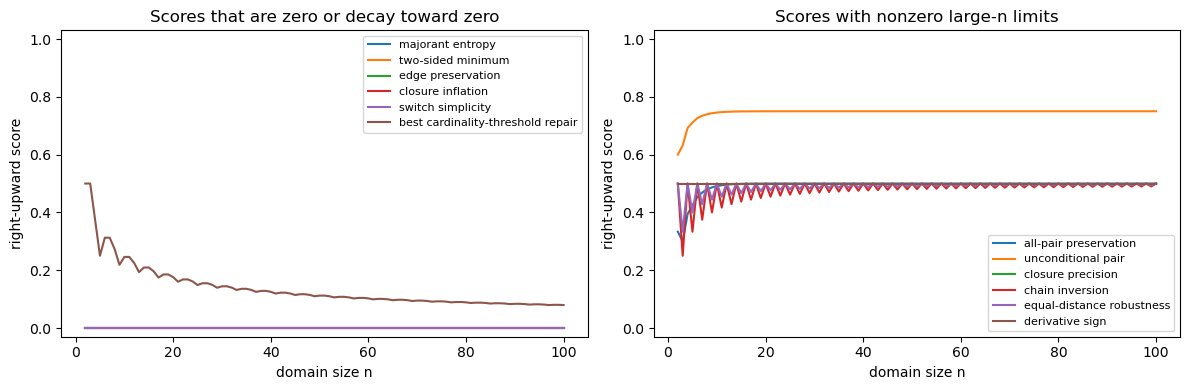

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

zero_or_decaying = {
    "majorant_entropy": "majorant entropy",
    "two_sided_min": "two-sided minimum",
    "edge_preservation": "edge preservation",
    "closure_inflation": "closure inflation",
    "chain_switch": "switch simplicity",
    "cardinality_threshold_edit": "best cardinality-threshold repair",
}
nonzero_limits = {
    "pairwise_preservation": "all-pair preservation",
    "unconditional_pair": "unconditional pair",
    "closure_precision": "closure precision",
    "chain_inversion": "chain inversion",
    "equal_distance_robustness": "equal-distance robustness",
    "derivative_sign": "derivative sign",
}

for column, label in zero_or_decaying.items():
    axes[0].plot(parity_scaling.index, parity_scaling[column], label=label)
for column, label in nonzero_limits.items():
    axes[1].plot(parity_scaling.index, parity_scaling[column], label=label)

axes[0].set_title("Scores that are zero or decay toward zero")
axes[1].set_title("Scores with nonzero large-n limits")
for ax in axes:
    ax.set(xlabel="domain size n", ylabel="right-upward score", ylim=(-0.03, 1.03))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### How to read the result

Your zero intuition is exactly right for metrics that ask whether **one-element
growth consistently preserves truth** or whether upward closure is useful:

- majorant entropy = `0` for every `n`, because the empty set is true and its
  upward closure is therefore the constant-true function;
- two-sided minimum = `0` for every `n`;
- edge preservation = `0` for every `n`, because adding one element always
  flips even cardinality to odd;
- closure inflation = `0` for every `n`;
- switch simplicity = `0` for every `n` in this normalization, because parity
  switches at every cardinality step.

The **best cardinality-threshold repair** also approaches zero, but slowly:
`0.375` at `n=4`, `0.246` at `n=10`, and `0.080` at `n=100`. This is the
large-domain result closest to "parity becomes arbitrarily far from a monotone
threshold." It is threshold-restricted in the sweep; at `n <= 12` it matches
the exact nearest-monotone min-cut values in direct checks (with regression
tests through `n=6`).

Other scores do **not** approach zero:

- all-pair preservation approaches `0.5`;
- unconditional pair score approaches `0.75`;
- closure precision, chain inversion, equal-distance robustness, and derivative
  sign are `0.5` (apart from small-size parity effects where applicable).

Those nonzero limits are not contradictions. They reveal different
denominators. For example, half of parity's nonzero one-step derivatives point
`0 -> 1` and half point `1 -> 0`, so derivative sign is exactly `0.5`; edge
preservation conditions only on true sources, all of which make the bad
`1 -> 0` transition, so it is exactly `0`.

**Bottom line:** if the desired intuition is "alternation should become
maximally nonmonotone," edge preservation, closure-based scores, switch
simplicity, and threshold repair express it. A generic pair average need not.

In [6]:
complement_pairs = [
    ("all A are B", "not all A are B"),
    ("some A are B", "no A are B"),
    ("at least two overlap", "at most one overlaps"),
    ("A equals B", "A differs from B"),
    ("A and B are comparable", "A and B are incomparable"),
    ("tautology", "contradiction"),
]
opposite = {"RU": "RD", "RD": "RU", "LU": "LD", "LD": "LU"}

scorecard_rows = []
for metric, label in METRICS.items():
    exact_values = df.loc[df.exact, metric]
    nonexact_values = df.loc[~df.exact, metric]
    mirror_errors = []
    for first, second in complement_pairs:
        for direction, mirror_direction in opposite.items():
            first_score = df.loc[
                (df.meaning == first) & (df.direction == direction), metric
            ].iloc[0]
            second_score = df.loc[
                (df.meaning == second)
                & (df.direction == mirror_direction),
                metric,
            ].iloc[0]
            mirror_errors.append(abs(first_score - second_score))
    ladder_values = ladder.loc[label].to_numpy()
    scorecard_rows.append(
        {
            "metric": label,
            "all exact directions = 1": np.allclose(exact_values, 1),
            "non-exact directions < 1": np.mean(nonexact_values < 1 - 1e-12),
            "ladder comparisons passed": sum(
                left > right
                for left, right in zip(ladder_values[:-1], ladder_values[1:])
            ),
            "max complement-mirror error": max(mirror_errors),
        }
    )

scorecard = pd.DataFrame(scorecard_rows).set_index("metric")
scorecard.round(3)

,all exact directions = 1,non-exact directions < 1,ladder comparisons passed,max complement-mirror error
metric,,,,
manuscript majorant entropy,True,1.000,3,0.432
two-sided entropy minimum,True,1.000,2,0.000
all-pair preservation,True,1.000,3,0.933
edge preservation,True,1.000,3,0.933
unconditional pair score,True,1.000,3,0.000
nearest-monotone edit,True,1.000,3,0.000
closure inflation,True,1.000,3,0.667
closure precision,True,1.000,3,0.744
chain switch simplicity,True,0.655,3,0.000


## 5. What the scorecard says

### Strong general-purpose candidates

**Nearest-monotone edit** is the cleanest global repair measure in this test:
it gets exact endpoints, the full intuition ladder, and complement symmetry.
Its interpretation is direct. Its costs are computational optimization and
dependence on the situation weights and chosen normalization.

**Edge preservation** is the cleanest local behavioral measure. It gets exact
endpoints and the ladder, and its events correspond to one-element
counterfactuals. It is not complement-invariant because it conditions on a
true source; that is a property of the estimand, not an implementation defect.

**Two-sided entropy minimum** passes the exact-endpoint and complement tests,
but only two of the three ladder comparisons because both the interval and
parity examples receive zero. Its values remain normalized information, not
percentages of preserved entailments or edits.

### Useful but narrower

**Closure inflation** is transparent and preserves the manuscript's one-sided
repair idea. Like the majorant entropy and closure precision, it is not
complement-invariant because adding false points and deleting true points are
different normalizations.

**Chain inversion** and **unconditional pair score** satisfy complement
symmetry. They differ mainly in weighting: the chain measure counts a pair once
for every maximal chain containing it, whereas the pair score counts each pair
once.

### Measures that fail as general directional scores

**Switch simplicity** assigns `1` to some non-exact directions. A clean
`1 -> 0` boundary has one switch and looks maximally simple even when testing
upward monotonicity. This is useful cognitive-organization information, but not
a directional monotonicity score.

**Best simple-threshold fit** answers whether a meaning resembles one
restricted cardinality-feature family. Exact monotone meanings outside that
family can still be penalized.

## 6. Local versus global behavior

The next table compares cases that expose denominator and locality effects.

In [7]:
representatives = [
    "all A are B",
    "most A are B",
    "exactly two overlap",
    "between one and three overlap",
    "even overlap",
    "A equals B",
    "A differs from B",
    "A and B are incomparable",
    "both empty or both nonempty",
]
columns = [
    "meaning",
    "exact",
    "majorant_entropy",
    "pairwise_preservation",
    "edge_preservation",
    "nearest_monotone_edit",
    "closure_inflation",
    "chain_switch",
    "chain_inversion",
    "derivative_sign",
]
df[(df.direction == "RU") & df.meaning.isin(representatives)][columns].round(3)

,meaning,exact,majorant_entropy,pairwise_preservation,edge_preservation,nearest_monotone_edit,closure_inflation,chain_switch,chain_inversion,derivative_sign
0,all A are B,True,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
16,most A are B,True,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
28,exactly two overlap,False,0.750,0.438,0.500,0.759,0.936,0.896,0.917,0.750
32,between one and three overlap,False,0.962,0.972,0.986,0.988,0.988,0.979,0.969,0.964
36,even overlap,False,0.000,0.500,0.500,0.358,0.000,0.646,0.417,0.438
56,A equals B,False,0.327,0.000,0.000,0.062,0.729,0.938,0.896,0.500
60,A differs from B,False,0.047,0.933,0.933,0.062,0.062,0.938,0.896,0.500
68,A and B are incomparable,False,0.432,0.497,0.655,0.545,0.658,0.771,0.688,0.500
72,both empty or both nonempty,False,0.393,0.980,0.991,0.967,0.500,1.000,0.958,0.938


Three warnings emerge:

1. `between one and three overlap` is non-exact but receives very high local,
   pairwise, closure, edit, and threshold scores. On M4, its only upper boundary
   failure occurs at maximal overlap. The high values are honest finite-domain
   geometry, not evidence of exact monotonicity.
2. `A differs from B` receives high pair/edge preservation but very low edit
   and closure-inflation scores. Violations are rare **conditional events**, yet
   repairing all of them globally forces a large structural change.
3. `A equals B` gets high closure precision and switch simplicity despite zero
   upward preservation. Those measures reward a sparse organized boundary, not
   robust upward entailment.

## 7. Robustness curves: proposal 7 becomes distinct only after weighting

If `(x,y)` is sampled uniformly from all comparable pairs with `Q(x)=1`, then
counterfactual robustness is exactly all-pair preservation. A new metric appears
only after choosing a transformation distribution.

Here every expansion distance `k` receives equal weight. Undefined distances,
where no true source has such an expansion, are shown as missing rather than
vacuously scored `1`.

,robustness_k1,robustness_k2,robustness_k3,robustness_k4
meaning,,,,
B threshold with one exception,0.984,0.938,NaN,NaN
B has one to three elements,0.857,0.667,0.0,NaN
B has even cardinality,0.000,1.000,0.0,1.0


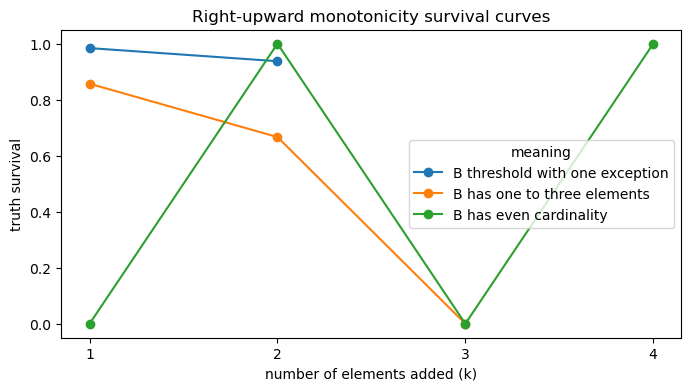

In [8]:
curve_names = [
    "B threshold with one exception",
    "B has one to three elements",
    "B has even cardinality",
]
curves = (
    df[(df.direction == "RU") & df.meaning.isin(curve_names)]
    .set_index("meaning")[
        ["robustness_k1", "robustness_k2", "robustness_k3", "robustness_k4"]
    ]
)
display(curves.round(3))

ax = curves.T.plot(marker="o", figsize=(8, 4))
ax.set(
    xlabel="number of elements added (k)",
    ylabel="truth survival",
    title="Right-upward monotonicity survival curves",
    xticks=range(4),
    xticklabels=[1, 2, 3, 4],
    ylim=(-0.05, 1.05),
)
plt.show()

The parity predicate alternates: survival is `0` at odd distances and `1` at
even distances. A single scalar conceals exactly the pattern that makes parity
intuitively irregular. For a learnability study, the curve or its first few
values may be more informative than an average.

## 8. Context-sensitive profiles

Global pairwise preservation weights contexts according to how many eligible
pairs they contribute. The context mean instead gives every fixed `A` equal
weight, but excludes contexts with no true-source prediction; `context_coverage`
reports how much of the context space was defined.

In [9]:
context_names = [
    "most A are B",
    "exactly two overlap",
    "A differs from B",
    "A and B are incomparable",
    "both empty or both nonempty",
]
df[(df.direction == "RU") & df.meaning.isin(context_names)][
    [
        "meaning",
        "pairwise_preservation",
        "context_mean",
        "context_sd",
        "context_coverage",
    ]
].round(3)

,meaning,pairwise_preservation,context_mean,context_sd,context_coverage
16,most A are B,1.000,1.000,0.000,0.938
28,exactly two overlap,0.438,0.636,0.404,0.688
60,A differs from B,0.933,0.936,0.056,1.000
68,A and B are incomparable,0.497,0.512,0.092,0.875
72,both empty or both nonempty,0.980,0.938,0.242,1.000


The standard deviation is not "more monotonicity"; it is a second axis:
**stability across restrictor contexts**. Reporting `(mean, SD, coverage)` is
more honest than folding all three into an undocumented scalar.

## 9. Directional profiles instead of a maximum

The maximum asks whether *some* direction is strong. It cannot distinguish one
clean direction from diffuse partial scores. The following uses edge
preservation because its units are easy to interpret.

In [10]:
profile_names = [
    "all A are B",
    "most A are B",
    "exactly two overlap",
    "A differs from B",
    "A and B are incomparable",
]
profiles = (
    df[df.meaning.isin(profile_names)]
    .pivot(index="meaning", columns="direction", values="edge_preservation")
    [["RU", "LU", "RD", "LD"]]
)
profiles["max"] = profiles.max(axis=1)
profiles["mean"] = profiles[["RU", "LU", "RD", "LD"]].mean(axis=1)
profiles["purity = max - mean"] = profiles["max"] - profiles["mean"]
profiles.round(3)

direction,RU,LU,RD,LD,max,mean,purity = max - mean
meaning,,,,,,,
A and B are incomparable,0.655,0.655,0.655,0.655,0.655,0.655,0.000
A differs from B,0.933,0.933,0.933,0.933,0.933,0.933,0.000
all A are B,1.000,0.500,0.500,1.000,1.000,0.750,0.250
exactly two overlap,0.500,0.500,0.250,0.250,0.500,0.375,0.125
most A are B,1.000,0.659,0.453,0.592,1.000,0.676,0.324


`purity` is not automatically desirable. A quantifier can be exactly monotone
in multiple directions. The scientifically useful object is the four-vector;
max, mean, and purity are optional hypotheses about what learners exploit.

## 10. Threshold and LoT proposals

### Threshold fit

The implemented candidate family is intentionally narrow. It searches
thresholds over simple features that are monotone in the tested direction:
overlap size, the varied-set size, directional set difference, and the
`overlap - nonoverlap` contrast used by `most`. Accuracy is maximized over the
feature and threshold.

This family can represent `all`, `some`, `most`, and simple cardinality
thresholds, but many monotone functions lie outside it. Its failures are useful
evidence against treating threshold fit as a general monotonicity score.

### Exception-code proxy

For minimum edit count `e` among `N` situations, the proxy code length is:

\[
\log_2\sum_{i=0}^{e}\binom{N}{i}.
\]

The reported score is one minus this code length divided by `N`. It rewards a
monotone base plus a short list of exceptions. It is **not** a full LoT result:
the monotone base itself is treated as free, all exception locations have the
same cost, and grammar/inference costs are omitted.

In [11]:
df[(df.direction == "RU") & df.meaning.isin(representatives)][
    [
        "meaning",
        "best_simple_threshold",
        "best_threshold_description",
        "edit_count",
        "exception_code_proxy",
    ]
].round(3)

,meaning,best_simple_threshold,best_threshold_description,edit_count,exception_code_proxy
0,all A are B,1.000,-(A-B) size >= 0,0,1.000
16,most A are B,1.000,overlap - (A-B) >= 1,0,1.000
28,exactly two overlap,0.949,overlap >= 2,13,0.722
32,between one and three overlap,0.996,overlap >= 1,1,0.969
36,even overlap,0.637,overlap >= 2,77,0.131
56,A equals B,0.941,overlap >= 4,15,0.690
60,A differs from B,0.938,overlap >= 0,15,0.690
68,A and B are incomparable,0.746,(B-A) size >= 1,50,0.302
72,both empty or both nonempty,0.938,B size >= 1,1,0.969


## 11. Recommendations for a learnability follow-up

### Primary candidates

1. **Edge preservation** for the hypothesis that learners exploit local
   one-element regularities.
2. **Nearest-monotone edit distance** for global truth-table repair cost.
3. **Majorant entropy** as the manuscript baseline, preserving comparability
   with the published analysis.

Keep all four directions for each metric. Do not replace the profile with a max
until the aggregation hypothesis is tested.

### Secondary diagnostics

- robustness curves by `k`;
- context mean, SD, and coverage;
- chain-switch simplicity as a separate boundary-complexity predictor;
- threshold/LoT fit as representational-simplicity predictors.

### What this notebook establishes

It establishes the measures' finite-universe behavior, endpoint properties,
complement symmetry, and response to hand-chosen semantic contrasts.

### What it does not establish

It does **not** show which metric predicts neural learnability best. That
requires computing these features for the 2,000 grammar-generated quantifiers
and comparing held-out model fit or predictive performance against AUC. The
best next experiment is a preregistered model comparison with manuscript
entropy, edge preservation, nearest edit, switch simplicity, and context
stability entered as separate predictors.